# Term Deposit Marketing - Modeling

### Data Load

In [36]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

In [37]:
file_path = r"../data/term-deposit-marketing-2020.csv"
df = pd.read_csv(file_path)
# df.info()
# df.describe()
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,no


In [38]:
# Target
y = (df["y"] == "yes").astype(int)
X = df.drop(columns=["y", "duration", "month", "day"])
# X["is_student_or_retired"] = df["job"].isin(["student", "retired"]).astype(int)
# X["low_campaign_flag"] = (df["campaign"] <= 2).astype(int)
# X["balance_bin"] = pd.qcut(df["balance"], 5, labels=False)

numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object", "str"]).columns

X_encoded = pd.get_dummies(X, columns=categorical_cols)
X_encoded.drop(["default_no", "housing_no", "loan_no"], axis=1, inplace=True)
X_encoded.drop(["job_unknown", "education_unknown", "contact_unknown"], axis=1, inplace=True)


### Helper Functions

In [39]:
def eval_model_cv(model, X, y):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    scoring = {
        "accuracy": "accuracy",
        "precision": make_scorer(precision_score),
        "recall": make_scorer(recall_score),
        "f1": make_scorer(f1_score),
    }

    cv_results = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=True
    )

    train_results = {
        metric: np.mean(cv_results[f"train_{metric}"])
        for metric in scoring.keys()
    }

    test_results = {
        metric: np.mean(cv_results[f"test_{metric}"])
        for metric in scoring.keys()
    }

    return train_results, test_results

In [40]:
from sklearn.inspection import permutation_importance
def get_important_features(model, X, y):
    model.fit(X, y)

    perm = permutation_importance(
        model,
        X,
        y,
        n_repeats=10,
        random_state=42,
        n_jobs=-1
    )

    importance_df = pd.DataFrame({
        "feature": X.columns,
        "importance": perm.importances_mean
    }).sort_values("importance", ascending=False)

    return importance_df

In [41]:
def get_lift(model, X, y, df):
    model.fit(X, y)
    probs = model.predict_proba(X)[:, 1]

    df_eval = df.copy()
    df_eval["pred_prob"] = probs

    # Create Deciles
    df_eval["decile"] = pd.qcut(df_eval["pred_prob"], 10, labels=False, duplicates="drop")
    lift_table = df_eval.groupby("decile")["y"].apply(lambda x: (x=="yes").mean()).sort_index(ascending=False)
    return lift_table, df_eval

In [42]:
def get_cum_pos_pct(df_eval):
    # Sort by predicted probability descending
    df_prob = df_eval.sort_values("pred_prob", ascending=False).reset_index(drop=True)

    # Create cumulative percentage of population
    df_prob["cum_population_pct"] = np.arange(1, len(df_prob)+1) / len(df_prob)

    # Create cumulative buyers captured
    df_prob["cum_positives"] = (df_prob["y"] == "yes").cumsum()

    total_positives = (df_prob["y"] == "yes").sum()

    df_prob["cum_positive_pct"] = df_prob["cum_positives"] / total_positives

    return df_prob, total_positives

### Modeling and Evaluation

#### Base Model - Logistic Regression

In [43]:
log = LogisticRegression(max_iter=20000, class_weight="balanced")
# log.fit(X_encoded, y)

# coef_df = pd.Series(log.coef_[0], index=X_encoded.columns)
# coef_df.sort_values(ascending=False).head(15)

In [44]:
train_results, test_results = eval_model_cv(log, X_encoded, y)
print(train_results)
print(test_results)

importance_df = get_important_features(log, X_encoded, y)
importance_df.head(15)

{'accuracy': np.float64(0.57808125), 'precision': np.float64(0.10552878333631237), 'recall': np.float64(0.6457183631087486), 'f1': np.float64(0.18140953987604425)}
{'accuracy': np.float64(0.5767), 'precision': np.float64(0.10419979432019792), 'recall': np.float64(0.638119826097314), 'f1': np.float64(0.17914208341565654)}


,feature,importance
15,marital_married,0.017898
16,marital_single,0.010578
2,campaign,0.006540
22,loan_yes,0.003760
0,age,0.003618
23,contact_cellular,0.003068
4,job_blue-collar,0.002762
14,marital_divorced,0.002428
24,contact_telephone,0.001715
1,balance,0.001425


In [45]:
lift_table, df_eval = get_lift(log, X_encoded, y, df)
lift_table

decile
9    0.16000
8    0.10850
7    0.08925
6    0.07850
5    0.06925
4    0.05625
3    0.05575
2    0.04500
1    0.03325
0    0.02825
Name: y, dtype: float64

In [46]:
df_logreg, total_positives = get_cum_pos_pct(df_eval)

for pct in [0.1, 0.2, 0.3, 0.5]:
    subset = df_logreg[df_logreg["cum_population_pct"] <= pct]
    captured = subset["y"].eq("yes").sum() / total_positives
    print(f"Top {int(pct*100)}% captures {captured:.2%} of buyers")

Top 10% captures 22.10% of buyers
Top 20% captures 37.09% of buyers
Top 30% captures 49.41% of buyers
Top 50% captures 69.82% of buyers


#### Decision Tree

In [47]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

In [48]:
train_results, test_results = eval_model_cv(tree, X_encoded, y)

print(train_results)
print(test_results)

importance_df = get_important_features(tree, X_encoded, y)
importance_df.head(15)

{'accuracy': np.float64(0.62051875), 'precision': np.float64(0.11249122029874421), 'recall': np.float64(0.6105844911419165), 'f1': np.float64(0.18955742062530917)}
{'accuracy': np.float64(0.6159), 'precision': np.float64(0.10595502519955546), 'recall': np.float64(0.5759662914656661), 'f1': np.float64(0.17857566268251188)}


,feature,importance
15,marital_married,0.008655
19,education_tertiary,0.003165
0,age,0.002323
2,campaign,0.002105
1,balance,0.001110
13,job_unemployed,0.000040
12,job_technician,0.000010
3,job_admin,0.000000
4,job_blue-collar,0.000000
8,job_retired,0.000000


In [49]:
lift_table, df_eval = get_lift(tree, X_encoded, y, df)
lift_table

decile
8    0.179766
7    0.104674
6    0.104312
5    0.082027
4    0.068654
3    0.056987
2    0.051129
1    0.037095
0    0.028597
Name: y, dtype: float64

In [50]:
df_dtree, total_positives = get_cum_pos_pct(df_eval)

for pct in [0.1, 0.2, 0.3, 0.5]:
    subset = df_dtree[df_dtree["cum_population_pct"] <= pct]
    captured = subset["y"].eq("yes").sum() / total_positives
    print(f"Top {int(pct*100)}% captures {captured:.2%} of buyers")

Top 10% captures 24.00% of buyers
Top 20% captures 37.33% of buyers
Top 30% captures 49.86% of buyers
Top 50% captures 70.58% of buyers


#### HistGradiantBoosting

In [51]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(
    max_depth=None,
    learning_rate=0.05,
    max_iter=300,
    random_state=42,
    class_weight="balanced"
)


In [52]:
train_results, test_results = eval_model_cv(hgb, X_encoded, y)
print(train_results)
print(test_results)

importance_df = get_important_features(hgb, X_encoded, y)
importance_df.head(15)

{'accuracy': np.float64(0.67321875), 'precision': np.float64(0.13771188688786778), 'recall': np.float64(0.6672994454892612), 'f1': np.float64(0.22829378359389305)}
{'accuracy': np.float64(0.659975), 'precision': np.float64(0.11551193301170377), 'recall': np.float64(0.555593472693705), 'f1': np.float64(0.19124100733095672)}


,feature,importance
2,campaign,0.013680
1,balance,0.007140
15,marital_married,0.007080
23,contact_cellular,0.006387
0,age,0.005087
12,job_technician,0.002242
16,marital_single,0.001870
22,loan_yes,0.001817
7,job_management,0.001472
4,job_blue-collar,0.001020


In [53]:
lift_table, df_eval = get_lift(hgb, X_encoded, y, df)
lift_table

decile
9    0.207250
8    0.135250
7    0.096000
6    0.080290
5    0.063984
4    0.048738
3    0.036500
2    0.030758
1    0.018245
0    0.007000
Name: y, dtype: float64

In [54]:
df_hgb, total_positives = get_cum_pos_pct(df_eval)

for pct in [0.1, 0.2, 0.3, 0.5]:
    subset = df_hgb[df_hgb["cum_population_pct"] <= pct]
    captured = subset["y"].eq("yes").sum() / total_positives
    print(f"Top {int(pct*100)}% captures {captured:.2%} of buyers")

Top 10% captures 28.63% of buyers
Top 20% captures 47.31% of buyers
Top 30% captures 60.57% of buyers
Top 50% captures 80.49% of buyers


#### Gains Chart

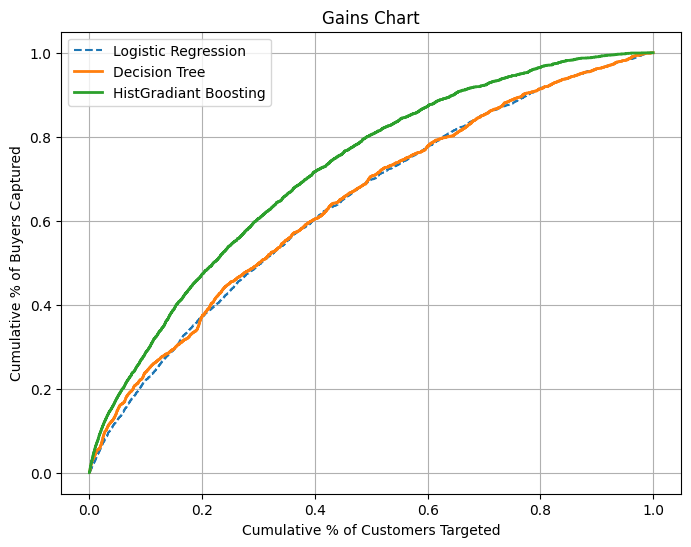

In [55]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))

# Logistic Regression (Baseline)
plt.plot(
    df_logreg["cum_population_pct"],
    df_logreg["cum_positive_pct"],
    label="Logistic Regression",
    linestyle="--",
)

# Decision Tree Gains Curve
plt.plot(
    df_dtree["cum_population_pct"],
    df_dtree["cum_positive_pct"],
    label="Decision Tree",
    linewidth=2
)


# HistGradiantBoosting Gains Curve
plt.plot(
    df_hgb["cum_population_pct"],
    df_hgb["cum_positive_pct"],
    label="HistGradiant Boosting",
    linewidth=2
)

plt.xlabel("Cumulative % of Customers Targeted")
plt.ylabel("Cumulative % of Buyers Captured")
plt.title("Gains Chart")
plt.legend()
plt.grid(True)
plt.show()
